# Realized Variance per Auction Round (ETH/USDT)

This notebook computes realized variance of ETH price for each resolved auction round by summing squared 1-second log returns between `round_start_timestamp` and `round_end_timestamp`.

- Source auctions: `onchain_data/auction_resolved.tsv`
- Source klines: `binance_klines/ETHUSDT-1s-*.csv`
- Output: a copy of the auction table with `realized_variance` column


In [1]:
from __future__ import annotations

import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

BASE_DIR = "/Users/kosunghun/codes/research/matroos_research/timeboost/tables_for_akaki"
AUCTIONS_PATH = os.path.join(BASE_DIR, "onchain_data", "auction_resolved.tsv")
KLINES_DIR = os.path.join(BASE_DIR, "binance_klines")
PAIR_PREFIX = "ETHUSDT-1s-"

# Read auctions (tab-separated)
auctions = pd.read_csv(AUCTIONS_PATH, sep="\t")
auctions.head()

,block_number,log_index,transaction_hash,contract_address,is_multi_bid_auction,round,first_price_bidder,first_price_express_lane_controller,first_price_amount,price,round_start_timestamp,round_end_timestamp
0,327331207,1,0x89b629162ca8f29b4a10dd99838086f4424a8c497e10...,0x5fcb496a31b7ae91e7c9078ec662bd7a55cd3079,False,53516,0x62197d23c0b04c8f78ee7dd07674218f02fafe34,0x62197d23c0b04c8f78ee7dd07674218f02fafe34,2155000000000000,1000000000000000,1744898031,1744898090
1,327373429,1,0x3f2e332d801a0337edec7ab2fe8746a731bc57fb59e8...,0x5fcb496a31b7ae91e7c9078ec662bd7a55cd3079,True,53691,0x95c0d21482fd6bc204e588c06632fdb1cf51b018,0x95c0d21482fd6bc204e588c06632fdb1cf51b018,2682014759447370,1000000000000000,1744908531,1744908590
2,327373668,1,0x52a8fe630b669204000dfcdc77ee99e48ae2e812dbfc...,0x5fcb496a31b7ae91e7c9078ec662bd7a55cd3079,False,53692,0x2b38a73dd32a2eafe849825a4b515ae5187eda42,0x2b38a73dd32a2eafe849825a4b515ae5187eda42,2937406002002699,1000000000000000,1744908591,1744908650
3,327374145,1,0x681b256e4c6f292435bb8cb71577d4f31716b031b03f...,0x5fcb496a31b7ae91e7c9078ec662bd7a55cd3079,False,53694,0x2b38a73dd32a2eafe849825a4b515ae5187eda42,0x2b38a73dd32a2eafe849825a4b515ae5187eda42,1000000000000000,1000000000000000,1744908711,1744908770
4,327374384,1,0xfc2601edbf98a06a234cb02ffac36bf14ab54533ca3c...,0x5fcb496a31b7ae91e7c9078ec662bd7a55cd3079,True,53695,0x95c0d21482fd6bc204e588c06632fdb1cf51b018,0x95c0d21482fd6bc204e588c06632fdb1cf51b018,2680071177704301,1000000000000000,1744908771,1744908830


In [2]:
# Load ETHUSDT 1-second klines CSVs
csv_paths = sorted(glob.glob(os.path.join(KLINES_DIR, f"{PAIR_PREFIX}*.csv")))
if not csv_paths:
    raise FileNotFoundError("No ETHUSDT 1s kline CSVs found")

# Binance 1s klines columns (no header). We'll assign names.
# Format per line:
# open_time_us, open, high, low, close, volume, close_time_us, quote_asset_volume,
# number_of_trades, taker_buy_base_asset_volume, taker_buy_quote_asset_volume, ignore
colnames = [
    "open_time_us",
    "open",
    "high",
    "low",
    "close",
    "volume",
    "close_time_us",
    "quote_asset_volume",
    "number_of_trades",
    "taker_buy_base_asset_volume",
    "taker_buy_quote_asset_volume",
    "ignore",
]

klines_list = []
for p in csv_paths:
    df = pd.read_csv(p, header=None, names=colnames)
    klines_list.append(df[["open_time_us", "open"]])

klines = pd.concat(klines_list, ignore_index=True)
# Convert microseconds to seconds (integer epoch seconds)
klines["ts_sec"] = (klines["open_time_us"] // 1_000_000).astype(np.int64)
# Use open price as 1s price
klines = klines[["ts_sec", "open"]]
klines = (
    klines.drop_duplicates(subset="ts_sec").sort_values("ts_sec").reset_index(drop=True)
)
klines.head()

,ts_sec,open
0,1743465600,1822.43
1,1743465601,1822.43
2,1743465602,1822.43
3,1743465603,1822.43
4,1743465604,1822.42


In [3]:
# Compute log returns (per second) and cumulative sum of squared returns
klines = klines.sort_values("ts_sec").reset_index(drop=True)
price = klines["open"].astype(float)
log_price = np.log(price)
log_ret = log_price.diff()
# Drop the first NaN; align with ts_sec
klr = pd.DataFrame(
    {
        "ts_sec": klines["ts_sec"].iloc[1:].values,
        "log_ret": log_ret.iloc[1:].values,
    }
)
klr["sq_log_ret"] = klr["log_ret"] ** 2
# cumulative sum for O(1) interval queries
klr["cumsum_sq"] = klr["sq_log_ret"].cumsum()
klr.head()

,ts_sec,log_ret,sq_log_ret,cumsum_sq
0,1743465601,0.000000,0.000000e+00,0.000000e+00
1,1743465602,0.000000,0.000000e+00,0.000000e+00
2,1743465603,0.000000,0.000000e+00,0.000000e+00
3,1743465604,-0.000005,3.010930e-11,3.010930e-11
4,1743465605,-0.000132,1.734534e-08,1.737545e-08


In [4]:
# Prepare auctions time columns as integer epoch seconds
# The file uses second-level epoch timestamps per earlier inspection
auctions = auctions.copy()
auctions["round_start_timestamp"] = auctions["round_start_timestamp"].astype(np.int64)
auctions["round_end_timestamp"] = auctions["round_end_timestamp"].astype(np.int64)
# Ensure start <= end
auctions = auctions[
    auctions["round_end_timestamp"] >= auctions["round_start_timestamp"]
].reset_index(drop=True)
len(auctions)

205679

In [5]:
# Compute realized variance per auction round via cumulative sums
# We join auctions' start/end to nearest available return timestamp boundaries.

# Build an index for fast boundary lookup
klr_idx = klr.set_index("ts_sec")["cumsum_sq"].sort_index()

# For inclusive range [start, end], returns exist for seconds >= first ret second.
# We'll align start to the first ts >= start, and end to the last ts <= end.
klr_times = klr_idx.index.values


def left_bound(ts: int) -> int:
    # first index where klr_times[idx] >= ts
    idx = np.searchsorted(klr_times, ts, side="left")
    return idx


def right_bound(ts: int) -> int:
    # last index where klr_times[idx] <= ts
    idx = np.searchsorted(klr_times, ts, side="right") - 1
    return idx


starts = auctions["round_start_timestamp"].to_numpy(dtype=np.int64)
ends = auctions["round_end_timestamp"].to_numpy(dtype=np.int64)

l_idx = np.array([left_bound(s) for s in starts])
r_idx = np.array([right_bound(e) for e in ends])

# Mask invalid cases where window has no returns
valid = (r_idx >= l_idx) & (r_idx >= 0) & (l_idx < len(klr_times))

# Fetch cumulative sums safely
cumsum_vals = klr_idx.values
left_cum = np.where(
    l_idx > 0, cumsum_vals[np.clip(l_idx - 1, 0, len(cumsum_vals) - 1)], 0.0
)
right_cum = np.where(
    valid, cumsum_vals[np.clip(r_idx, 0, len(cumsum_vals) - 1)], left_cum
)

realized_var = np.where(valid, right_cum - left_cum, np.nan)

auctions_with_rv = auctions.copy()
auctions_with_rv["realized_variance"] = realized_var
auctions_with_rv.head()

,block_number,log_index,transaction_hash,contract_address,is_multi_bid_auction,round,first_price_bidder,first_price_express_lane_controller,first_price_amount,price,round_start_timestamp,round_end_timestamp,realized_variance
0,327331207,1,0x89b629162ca8f29b4a10dd99838086f4424a8c497e10...,0x5fcb496a31b7ae91e7c9078ec662bd7a55cd3079,False,53516,0x62197d23c0b04c8f78ee7dd07674218f02fafe34,0x62197d23c0b04c8f78ee7dd07674218f02fafe34,2155000000000000,1000000000000000,1744898031,1744898090,6.321553e-07
1,327373429,1,0x3f2e332d801a0337edec7ab2fe8746a731bc57fb59e8...,0x5fcb496a31b7ae91e7c9078ec662bd7a55cd3079,True,53691,0x95c0d21482fd6bc204e588c06632fdb1cf51b018,0x95c0d21482fd6bc204e588c06632fdb1cf51b018,2682014759447370,1000000000000000,1744908531,1744908590,7.535266e-07
2,327373668,1,0x52a8fe630b669204000dfcdc77ee99e48ae2e812dbfc...,0x5fcb496a31b7ae91e7c9078ec662bd7a55cd3079,False,53692,0x2b38a73dd32a2eafe849825a4b515ae5187eda42,0x2b38a73dd32a2eafe849825a4b515ae5187eda42,2937406002002699,1000000000000000,1744908591,1744908650,6.096590e-07
3,327374145,1,0x681b256e4c6f292435bb8cb71577d4f31716b031b03f...,0x5fcb496a31b7ae91e7c9078ec662bd7a55cd3079,False,53694,0x2b38a73dd32a2eafe849825a4b515ae5187eda42,0x2b38a73dd32a2eafe849825a4b515ae5187eda42,1000000000000000,1000000000000000,1744908711,1744908770,5.242480e-07
4,327374384,1,0xfc2601edbf98a06a234cb02ffac36bf14ab54533ca3c...,0x5fcb496a31b7ae91e7c9078ec662bd7a55cd3079,True,53695,0x95c0d21482fd6bc204e588c06632fdb1cf51b018,0x95c0d21482fd6bc204e588c06632fdb1cf51b018,2680071177704301,1000000000000000,1744908771,1744908830,1.914002e-07


In [6]:
# Save augmented table and show a small sample
OUTPUT_TSV = os.path.join(
    BASE_DIR, "onchain_data", "auction_resolved_with_realized_variance.tsv"
)
auctions_with_rv.to_csv(OUTPUT_TSV, sep="\t", index=False)
print("Saved:", OUTPUT_TSV)
auctions_with_rv[
    ["round", "round_start_timestamp", "round_end_timestamp", "realized_variance"]
].head(10)

Saved: /Users/kosunghun/codes/research/matroos_research/timeboost/tables_for_akaki/onchain_data/auction_resolved_with_realized_variance.tsv


,round,round_start_timestamp,round_end_timestamp,realized_variance
0,53516,1744898031,1744898090,6.321553e-07
1,53691,1744908531,1744908590,7.535266e-07
2,53692,1744908591,1744908650,6.096590e-07
3,53694,1744908711,1744908770,5.242480e-07
4,53695,1744908771,1744908830,1.914002e-07
5,53696,1744908831,1744908890,2.695631e-07
6,53697,1744908891,1744908950,7.249650e-07
7,53698,1744908951,1744909010,7.755491e-07
8,53699,1744909011,1744909070,2.356185e-07
9,53700,1744909071,1744909130,1.205983e-07


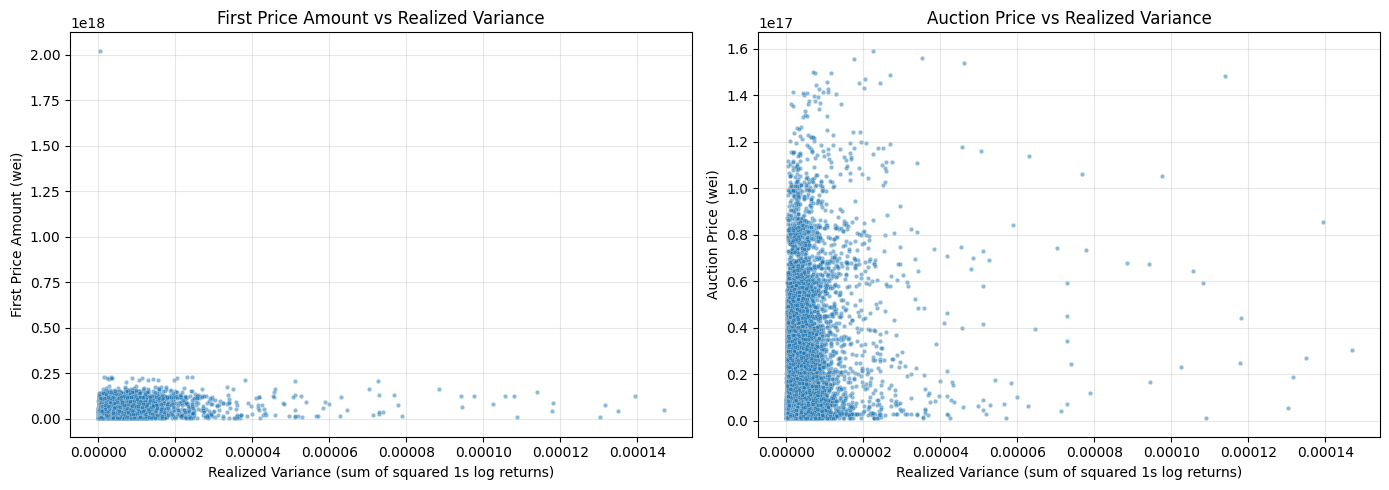

In [7]:
# Scatter plots: x = realized_variance, y = first_price_amount and price

plot_df = auctions_with_rv.copy()
plot_df = plot_df.replace([np.inf, -np.inf], np.nan).dropna(
    subset=["realized_variance"]
)  # ensure finite RV

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

sns.scatterplot(
    data=plot_df,
    x="realized_variance",
    y="first_price_amount",
    s=10,
    alpha=0.5,
    ax=axes[0],
)
axes[0].set_title("First Price Amount vs Realized Variance")
axes[0].set_xlabel("Realized Variance (sum of squared 1s log returns)")
axes[0].set_ylabel("First Price Amount (wei)")
axes[0].grid(True, alpha=0.3)

sns.scatterplot(
    data=plot_df,
    x="realized_variance",
    y="price",
    s=10,
    alpha=0.5,
    ax=axes[1],
)
axes[1].set_title("Auction Price vs Realized Variance")
axes[1].set_xlabel("Realized Variance (sum of squared 1s log returns)")
axes[1].set_ylabel("Auction Price (wei)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

/var/folders/mw/7dlhwf_52t93xrwvltvn_7nr0000gn/T/ipykernel_38587/2902085481.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means_first = box_df.groupby("rv_quantile")["first_price_amount"].mean().reindex(labels)
/var/folders/mw/7dlhwf_52t93xrwvltvn_7nr0000gn/T/ipykernel_38587/2902085481.py:44: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means_price = box_df.groupby("rv_quantile")["price"].mean().reindex(labels)


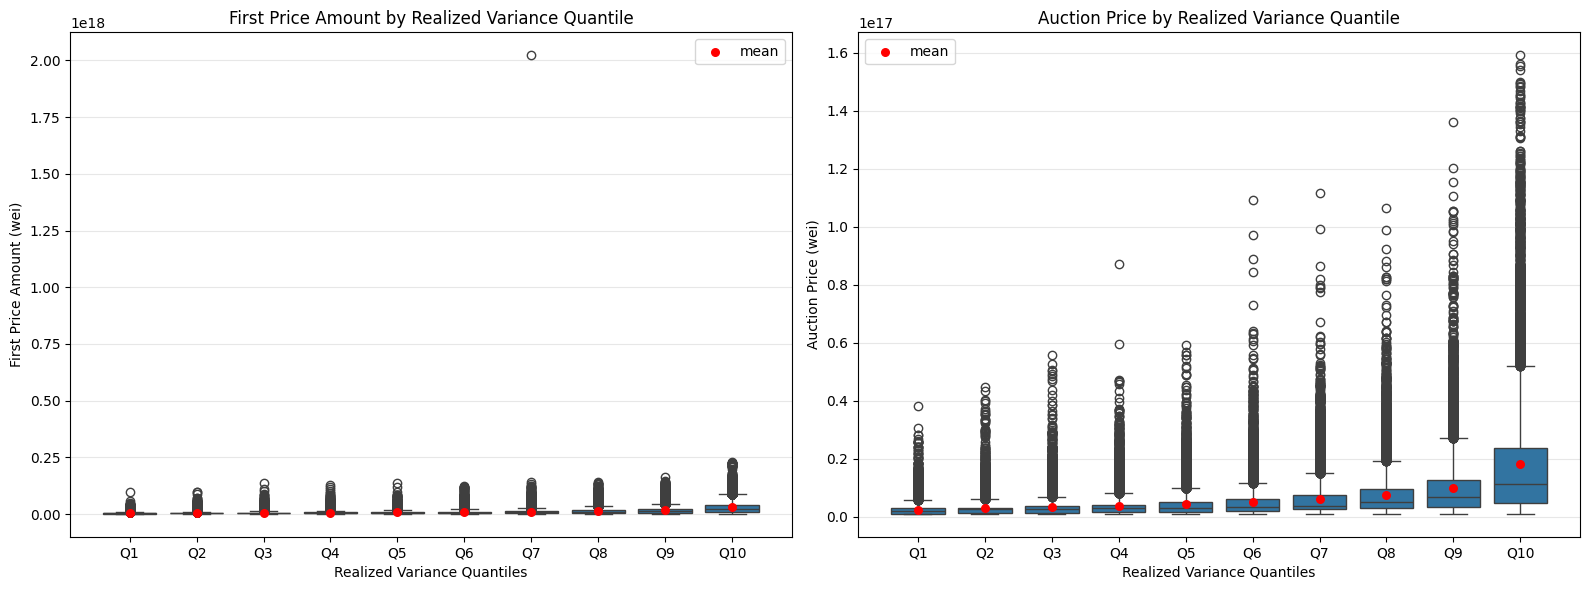

In [8]:
# Boxplots by realized variance quantiles (with mean overlay)

box_df = auctions_with_rv.copy()
box_df = box_df.replace([np.inf, -np.inf], np.nan).dropna(
    subset=["realized_variance"]
)  # ensure finite RV

# Choose number of quantile bins
num_bins = 10
labels = [f"Q{i + 1}" for i in range(num_bins)]
box_df["rv_quantile"] = pd.qcut(box_df["realized_variance"], q=num_bins, labels=labels)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=False)

# First price amount box + mean
sns.boxplot(
    data=box_df,
    x="rv_quantile",
    y="first_price_amount",
    ax=axes[0],
)
means_first = box_df.groupby("rv_quantile")["first_price_amount"].mean().reindex(labels)
axes[0].scatter(
    x=np.arange(len(labels)),
    y=means_first.values,
    color="red",
    s=30,
    zorder=3,
    label="mean",
)
axes[0].legend()
axes[0].set_title("First Price Amount by Realized Variance Quantile")
axes[0].set_xlabel("Realized Variance Quantiles")
axes[0].set_ylabel("First Price Amount (wei)")
axes[0].grid(True, axis="y", alpha=0.3)

# Auction price box + mean
sns.boxplot(
    data=box_df,
    x="rv_quantile",
    y="price",
    ax=axes[1],
)
means_price = box_df.groupby("rv_quantile")["price"].mean().reindex(labels)
axes[1].scatter(
    x=np.arange(len(labels)),
    y=means_price.values,
    color="red",
    s=30,
    zorder=3,
    label="mean",
)
axes[1].legend()
axes[1].set_title("Auction Price by Realized Variance Quantile")
axes[1].set_xlabel("Realized Variance Quantiles")
axes[1].set_ylabel("Auction Price (wei)")
axes[1].grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

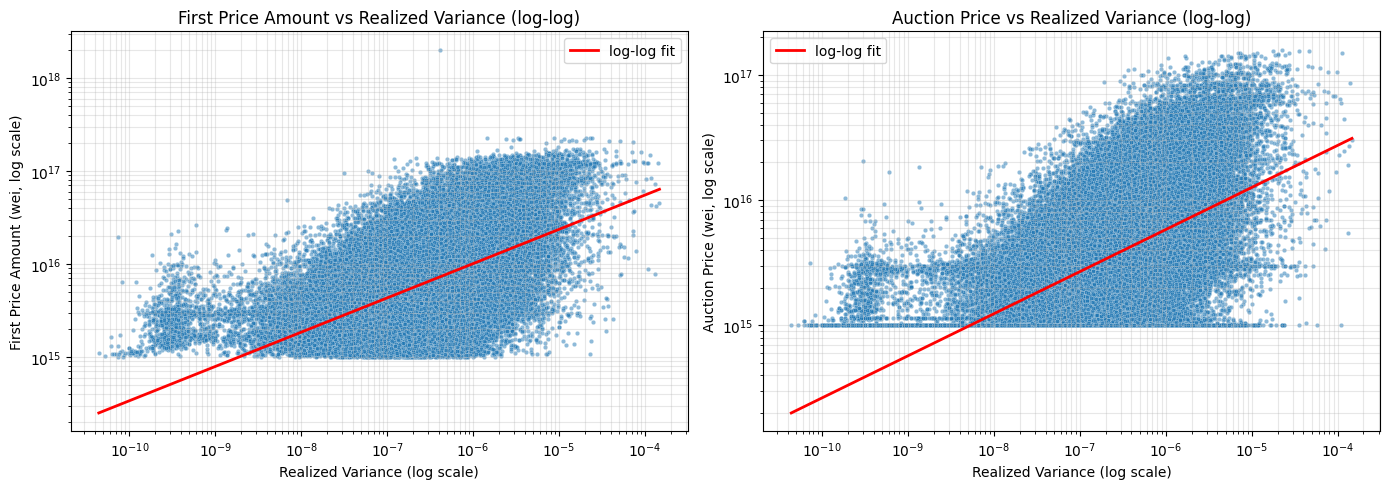

Regression coefficients (global log-log scatter):


,target,model,intercept,slope,n
0,first_price_amount,log-log,41.945699,0.368700,196097
1,price,log-log,40.940645,0.335908,196097


In [9]:
# Log-Log scatter plots: x = realized_variance, y = first_price_amount and price

log_df = auctions_with_rv.copy()
log_df = log_df.replace([np.inf, -np.inf], np.nan).dropna(
    subset=["realized_variance"]
)  # finite RV

# Filter to positive values for log scale
log_df = log_df[(log_df["realized_variance"] > 0)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

# First Price Amount scatter + regression line (log-log)
sns.scatterplot(
    data=log_df[(log_df["first_price_amount"] > 0)],
    x="realized_variance",
    y="first_price_amount",
    s=10,
    alpha=0.5,
    ax=axes[0],
)
axes[0].set_xscale("log")
axes[0].set_yscale("log")
# Fit regression on logs and overlay line
_df_fp = log_df[(log_df["first_price_amount"] > 0)][
    ["realized_variance", "first_price_amount"]
].dropna()
_X_fp = np.log(_df_fp["realized_variance"].values).reshape(-1, 1)
_y_fp_log = np.log(_df_fp["first_price_amount"].values)
_lr_fp = LinearRegression().fit(_X_fp, _y_fp_log)
_xline_fp = np.linspace(
    _df_fp["realized_variance"].min(), _df_fp["realized_variance"].max(), 200
)
_yline_fp = np.exp(_lr_fp.intercept_ + _lr_fp.coef_[0] * np.log(_xline_fp))
axes[0].plot(_xline_fp, _yline_fp, color="red", linewidth=2, label="log-log fit")
axes[0].legend()
axes[0].set_title("First Price Amount vs Realized Variance (log-log)")
axes[0].set_xlabel("Realized Variance (log scale)")
axes[0].set_ylabel("First Price Amount (wei, log scale)")
axes[0].grid(True, which="both", alpha=0.3)

# Auction Price scatter + regression line (log-log)
sns.scatterplot(
    data=log_df[(log_df["price"] > 0)],
    x="realized_variance",
    y="price",
    s=10,
    alpha=0.5,
    ax=axes[1],
)
axes[1].set_xscale("log")
axes[1].set_yscale("log")
_df_p = log_df[(log_df["price"] > 0)][["realized_variance", "price"]].dropna()
_X_p = np.log(_df_p["realized_variance"].values).reshape(-1, 1)
_y_p_log = np.log(_df_p["price"].values)
_lr_p = LinearRegression().fit(_X_p, _y_p_log)
_xline_p = np.linspace(
    _df_p["realized_variance"].min(), _df_p["realized_variance"].max(), 200
)
_yline_p = np.exp(_lr_p.intercept_ + _lr_p.coef_[0] * np.log(_xline_p))
axes[1].plot(_xline_p, _yline_p, color="red", linewidth=2, label="log-log fit")
axes[1].legend()
axes[1].set_title("Auction Price vs Realized Variance (log-log)")
axes[1].set_xlabel("Realized Variance (log scale)")
axes[1].set_ylabel("Auction Price (wei, log scale)")
axes[1].grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

# Print log-log regression coefficients for both targets
coeff_df = pd.DataFrame(
    [
        {
            "target": "first_price_amount",
            "model": "log-log",
            "intercept": float(_lr_fp.intercept_),
            "slope": float(_lr_fp.coef_[0]),
            "n": int(len(_X_fp)),
        },
        {
            "target": "price",
            "model": "log-log",
            "intercept": float(_lr_p.intercept_),
            "slope": float(_lr_p.coef_[0]),
            "n": int(len(_X_p)),
        },
    ]
)
print("Regression coefficients (global log-log scatter):")
display(coeff_df)

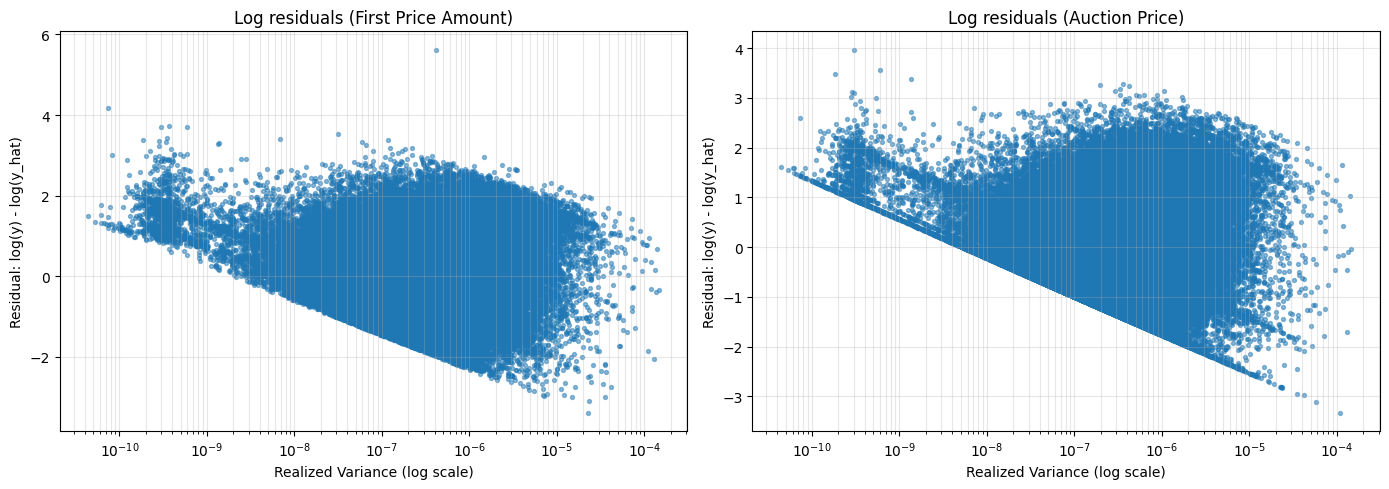

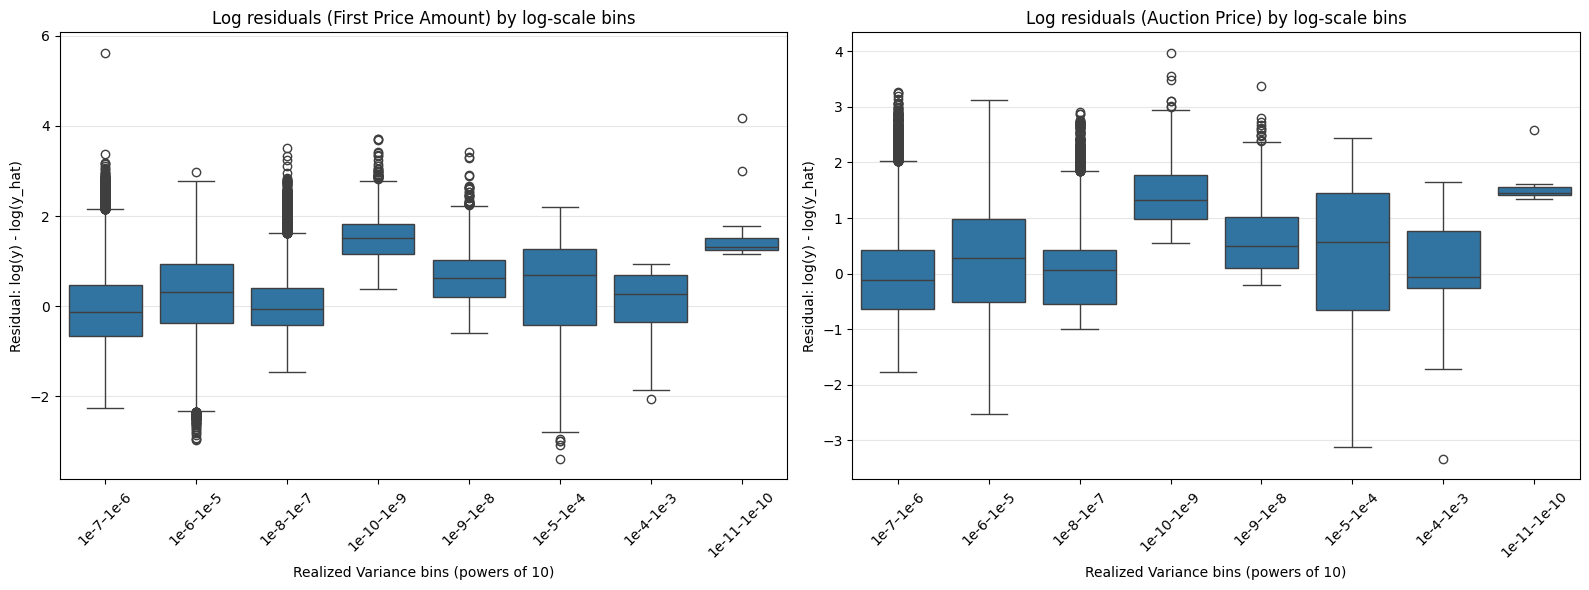

In [10]:
# Log-log linear regression residuals and binned boxplots
# We model: log(y) = a + b * log(x), where x = realized_variance, y in {first_price_amount, price}

res_df = auctions_with_rv.copy()
res_df = res_df.replace([np.inf, -np.inf], np.nan).dropna(
    subset=["realized_variance"]
)  # finite RV
res_df = res_df[(res_df["realized_variance"] > 0)]

# Helper to fit regression on log-log and compute residuals as log differences
# Residuals defined as log(y) - log(y_hat)


def fit_and_log_residuals(df, y_col):
    df_local = df[["realized_variance", y_col]].dropna().copy()
    df_local = df_local[(df_local[y_col] > 0)]
    X = np.log(df_local[["realized_variance"]].values)
    y_log = np.log(df_local[[y_col]].values).reshape(-1)
    lr = LinearRegression()
    lr.fit(X, y_log)
    y_hat_log = lr.predict(X).reshape(-1)
    resid_log = y_log - y_hat_log
    return df_local["realized_variance"].values, resid_log, lr


x_fp, resid_fp_log, lr_fp = fit_and_log_residuals(res_df, "first_price_amount")
x_p, resid_p_log, lr_p = fit_and_log_residuals(res_df, "price")

# Plot log residuals vs realized variance (both panels)
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

axes[0].scatter(x_fp, resid_fp_log, s=8, alpha=0.5)
axes[0].set_xscale("log")
axes[0].set_title("Log residuals (First Price Amount)")
axes[0].set_xlabel("Realized Variance (log scale)")
axes[0].set_ylabel("Residual: log(y) - log(y_hat)")
axes[0].grid(True, which="both", alpha=0.3)

axes[1].scatter(x_p, resid_p_log, s=8, alpha=0.5)
axes[1].set_xscale("log")
axes[1].set_title("Log residuals (Auction Price)")
axes[1].set_xlabel("Realized Variance (log scale)")
axes[1].set_ylabel("Residual: log(y) - log(y_hat)")
axes[1].grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

# Build log-scale bins from 10^k to 10^{k+1} spanning observed x range
all_x = np.concatenate([x_fp, x_p])
min_x, max_x = all_x.min(), all_x.max()
min_exp = int(np.floor(np.log10(min_x)))
max_exp = int(np.ceil(np.log10(max_x)))
bin_edges = np.power(10.0, np.arange(min_exp, max_exp + 1))

# Function to bin and boxplot log residuals


def box_by_log_bins(x, resid, title, ax):
    # Bin indices
    idx = np.digitize(x, bins=bin_edges, right=False)
    # Prepare DataFrame for seaborn
    bdf = pd.DataFrame(
        {
            "bin": idx,
            "resid_log": resid,
        }
    )
    # Keep bins in range
    bdf = bdf[(bdf["bin"] >= 1) & (bdf["bin"] <= len(bin_edges) - 1)]
    # Create labels like 10^{k}–10^{k+1}
    labels = [f"1e{e}–1e{e + 1}" for e in range(min_exp, max_exp)]
    bdf["bin_label"] = bdf["bin"].map(
        lambda i: labels[i - 1] if 1 <= i <= len(labels) else None
    )
    sns.boxplot(data=bdf, x="bin_label", y="resid_log", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Realized Variance bins (powers of 10)")
    ax.set_ylabel("Residual: log(y) - log(y_hat)")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(True, axis="y", alpha=0.3)


fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=False)
box_by_log_bins(
    x_fp, resid_fp_log, "Log residuals (First Price Amount) by log-scale bins", axes[0]
)
box_by_log_bins(
    x_p, resid_p_log, "Log residuals (Auction Price) by log-scale bins", axes[1]
)
plt.tight_layout()
plt.show()

In [11]:
# Identify top 3 winners by count and prepare subsets
aw = auctions_with_rv.copy()
aw = aw.replace([np.inf, -np.inf], np.nan)

# Determine top 3 by number of wins, tie-broken by total first_price_amount
winner_counts = (
    aw.groupby("first_price_bidder")
    .agg(
        wins=("round", "count"),
        total_first_price=("first_price_amount", "sum"),
    )
    .sort_values(["wins", "total_first_price"], ascending=[False, False])
)

top3_winners = winner_counts.head(3).index.tolist()
print("Top 3 winners:")
for i, w in enumerate(top3_winners, 1):
    stats = winner_counts.loc[w]
    print(
        f"{i}. {w} - wins={int(stats['wins'])}, total_first_price={int(stats['total_first_price'])}"
    )

# Build a dict of subsets
winner_subsets = {w: aw[aw["first_price_bidder"] == w].copy() for w in top3_winners}

# Quick sanity
{w: len(df) for w, df in winner_subsets.items()}

Top 3 winners:
1. 0x95c0d21482fd6bc204e588c06632fdb1cf51b018 - wins=116077, total_first_price=-5258302592749870534
2. 0x8c6ffc5501aca218f5f60e140d2c2461092ec3e2 - wins=74328, total_first_price=7006780247749349878
3. 0x2b38a73dd32a2eafe849825a4b515ae5187eda42 - wins=14061, total_first_price=-324198112382669810


{'0x95c0d21482fd6bc204e588c06632fdb1cf51b018': 116077,
 '0x8c6ffc5501aca218f5f60e140d2c2461092ec3e2': 74328,
 '0x2b38a73dd32a2eafe849825a4b515ae5187eda42': 14061}

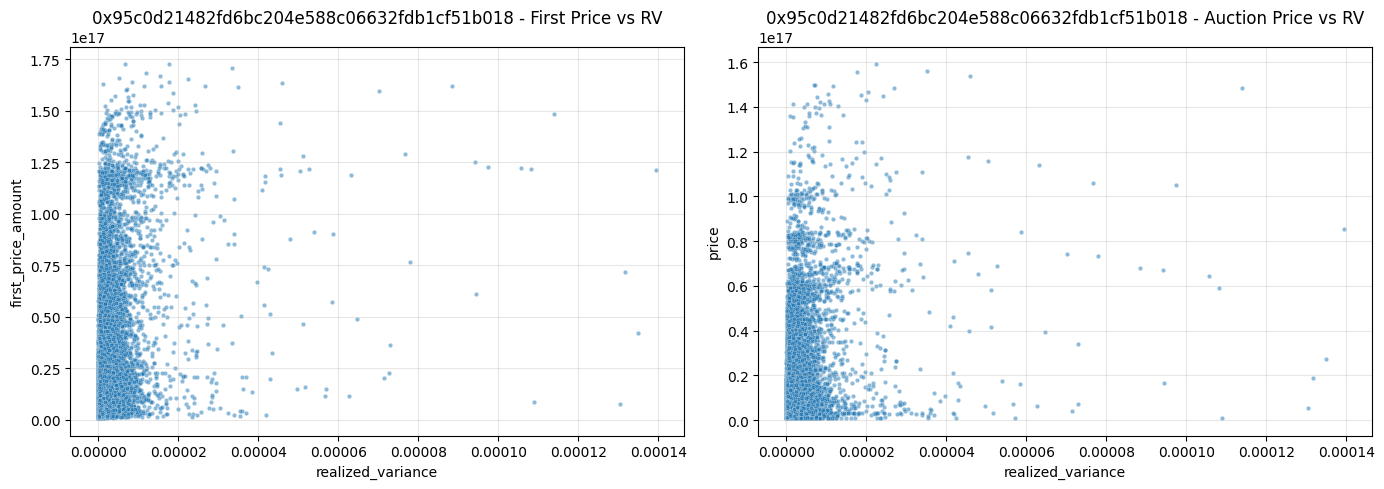

/var/folders/mw/7dlhwf_52t93xrwvltvn_7nr0000gn/T/ipykernel_38587/1828492159.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bdf.groupby("rv_quantile")["first_price_amount"].mean().reindex(labels)
/var/folders/mw/7dlhwf_52t93xrwvltvn_7nr0000gn/T/ipykernel_38587/1828492159.py:50: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means_price = bdf.groupby("rv_quantile")["price"].mean().reindex(labels)


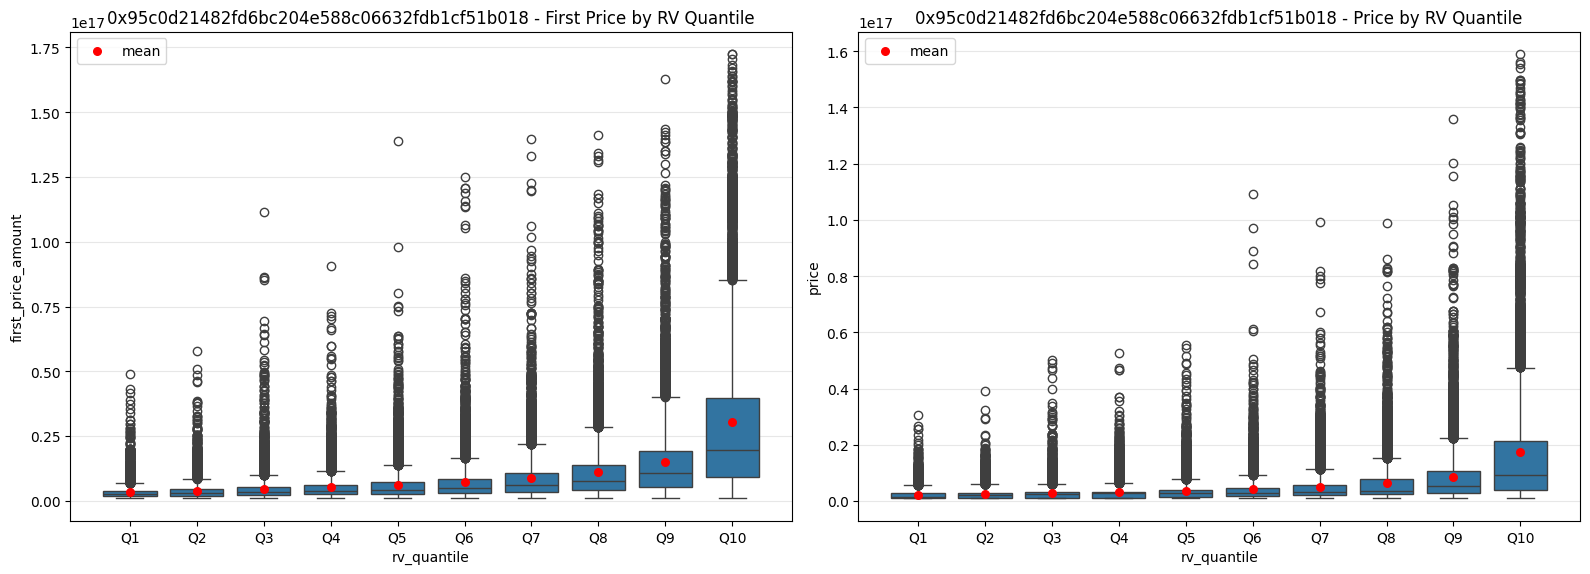

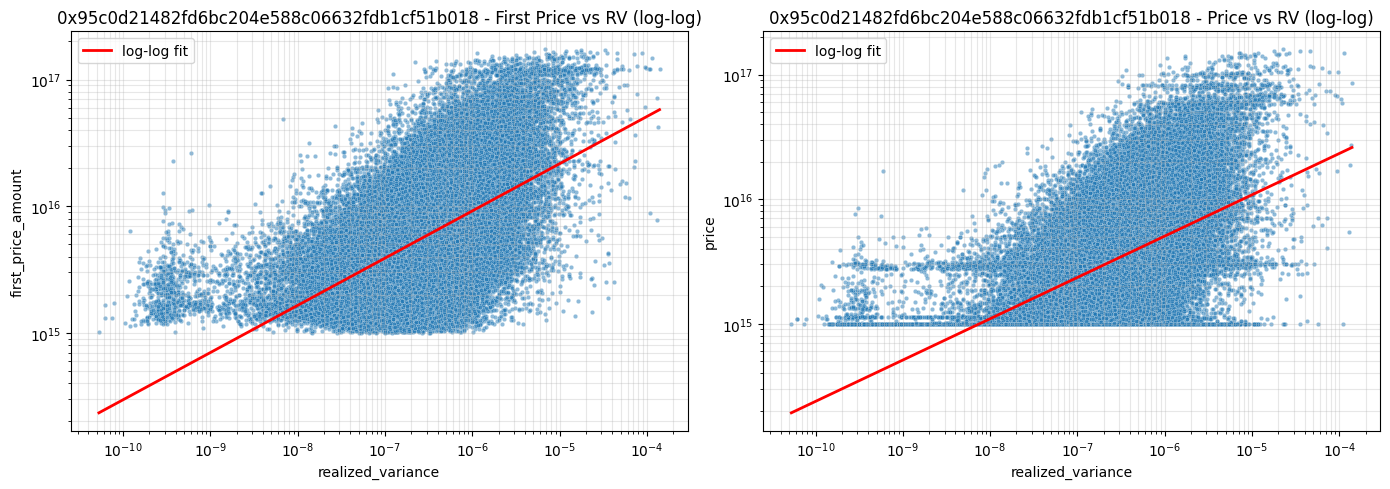

Regression coefficients for 0x95c0d21482fd6bc204e588c06632fdb1cf51b018 (log-log):


,winner,target,model,intercept,slope,n
0,0x95c0d21482fd6bc204e588c06632fdb1cf51b018,first_price_amount,log-log,41.903561,0.372562,110832
1,0x95c0d21482fd6bc204e588c06632fdb1cf51b018,price,log-log,40.741448,0.331683,110832


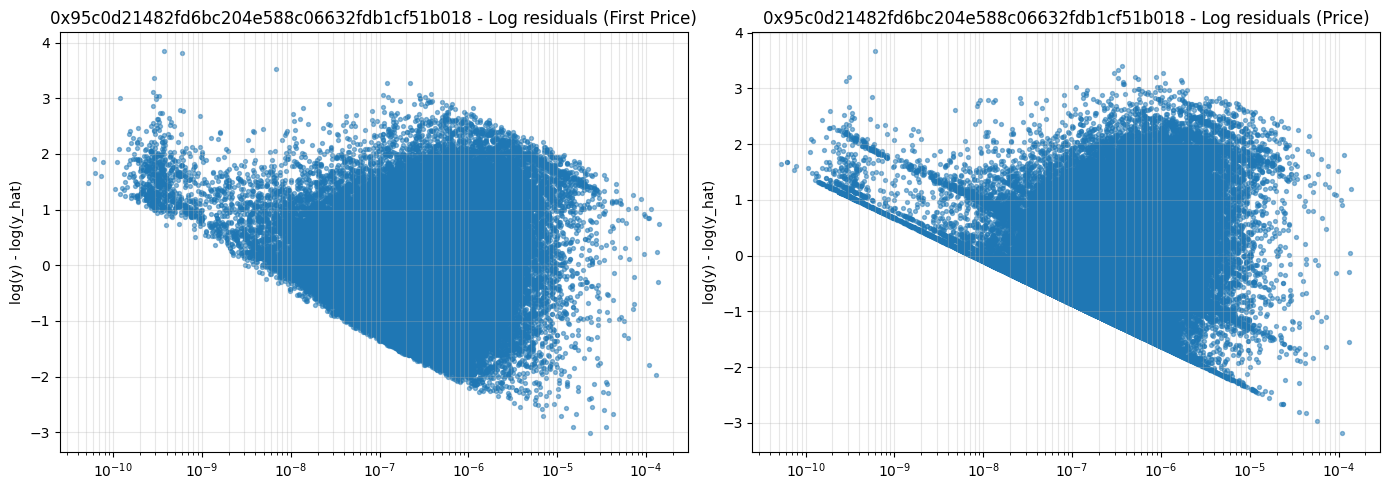

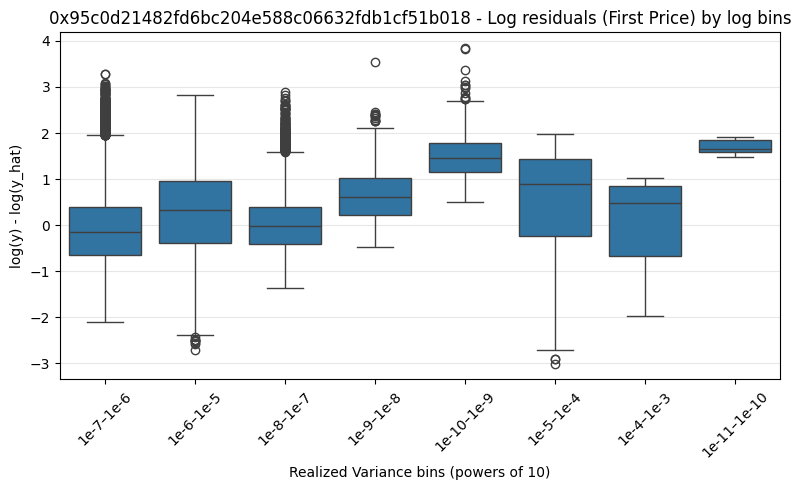

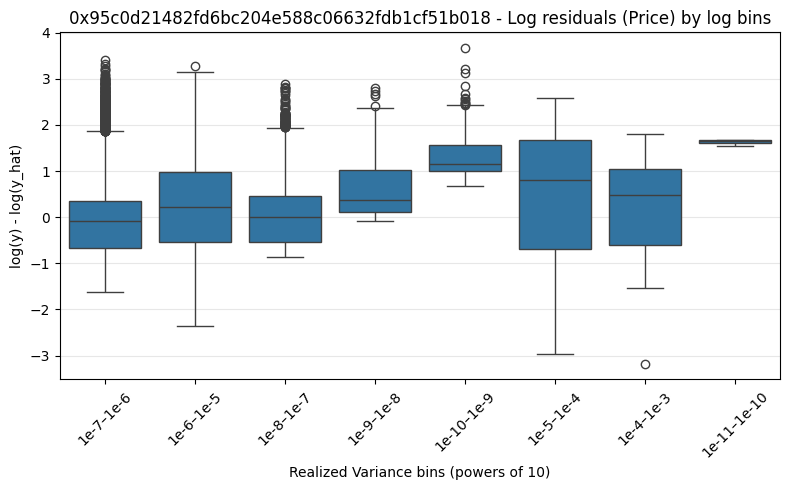

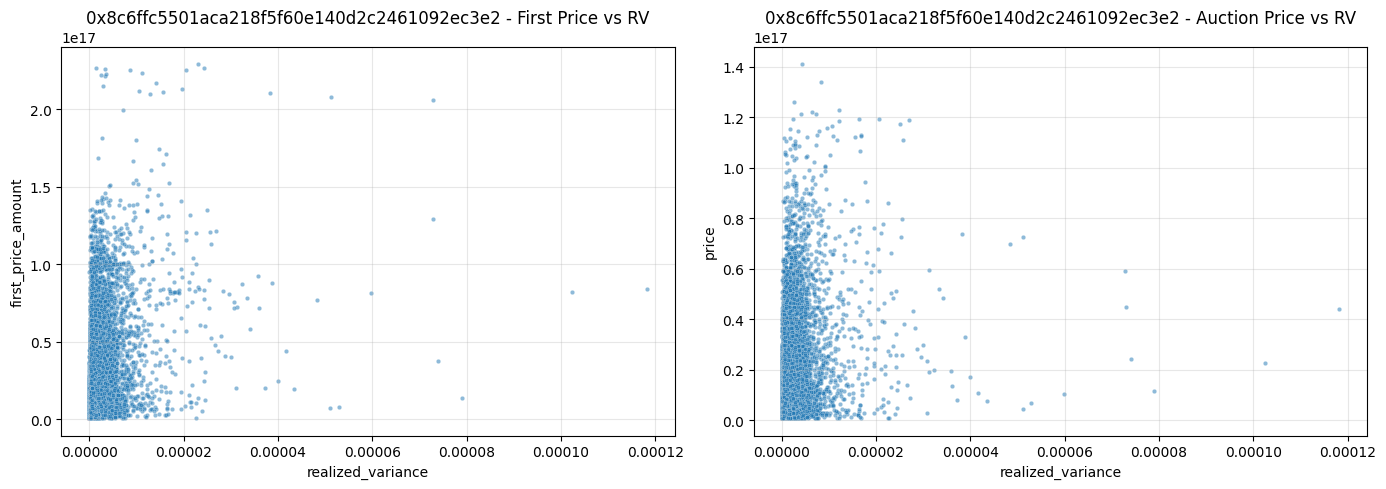

/var/folders/mw/7dlhwf_52t93xrwvltvn_7nr0000gn/T/ipykernel_38587/1828492159.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bdf.groupby("rv_quantile")["first_price_amount"].mean().reindex(labels)
/var/folders/mw/7dlhwf_52t93xrwvltvn_7nr0000gn/T/ipykernel_38587/1828492159.py:50: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means_price = bdf.groupby("rv_quantile")["price"].mean().reindex(labels)


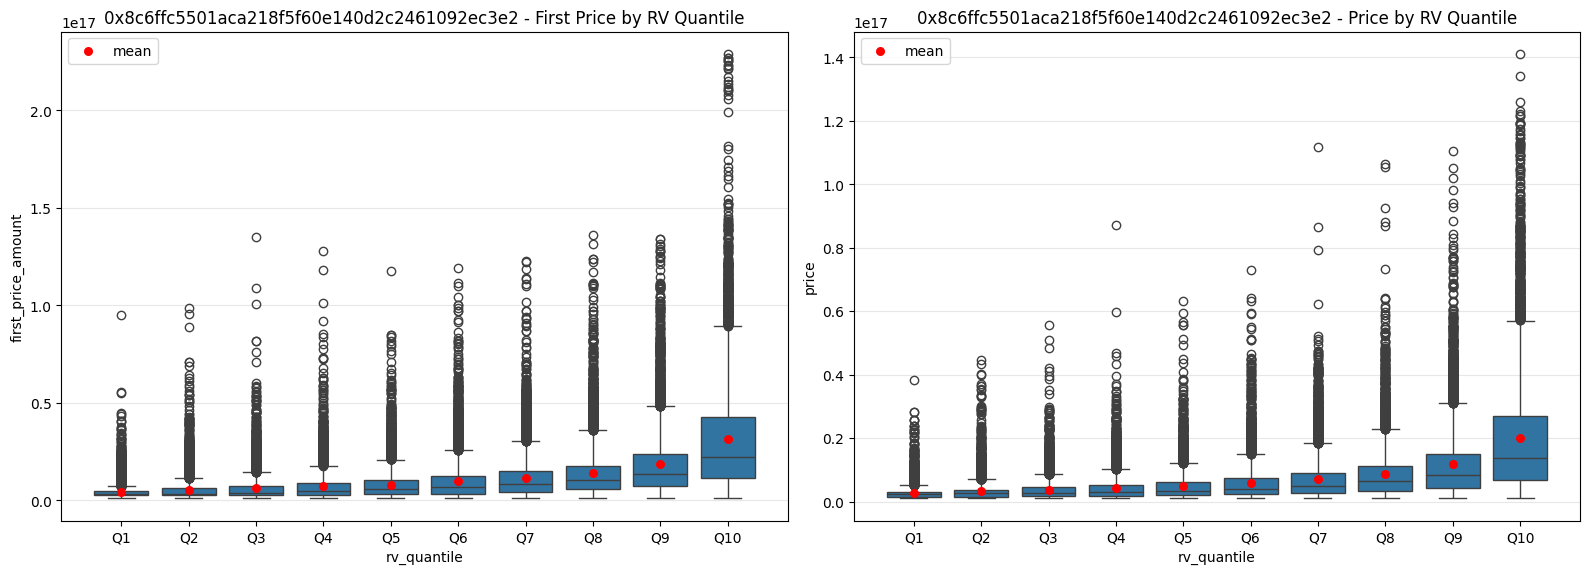

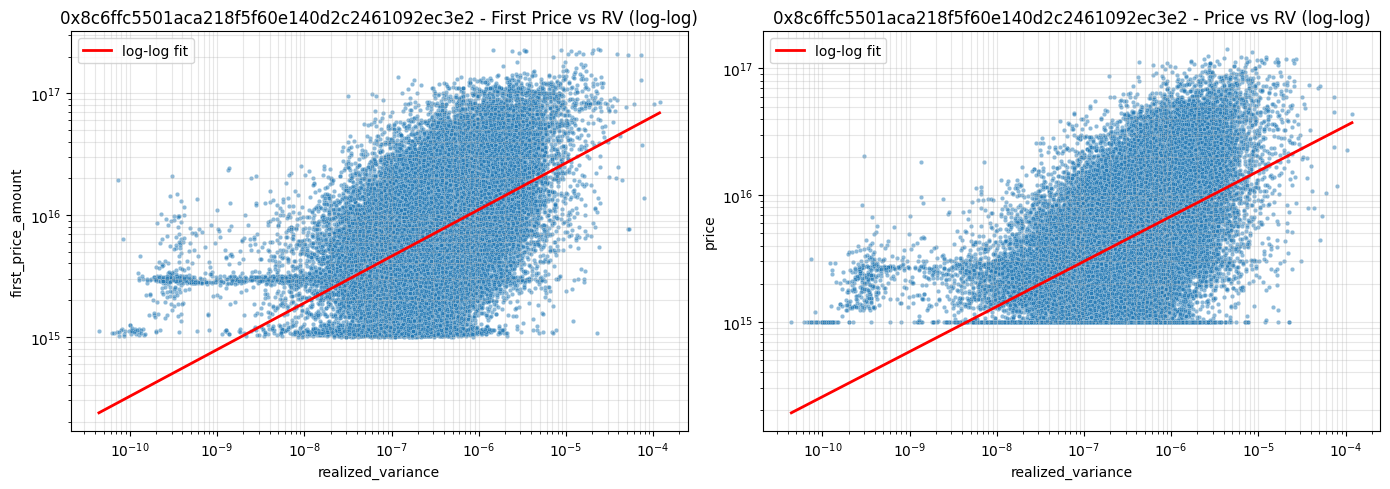

Regression coefficients for 0x8c6ffc5501aca218f5f60e140d2c2461092ec3e2 (log-log):


,winner,target,model,intercept,slope,n
0,0x8c6ffc5501aca218f5f60e140d2c2461092ec3e2,first_price_amount,log-log,42.239646,0.383324,70454
1,0x8c6ffc5501aca218f5f60e140d2c2461092ec3e2,price,log-log,41.379223,0.356189,70454


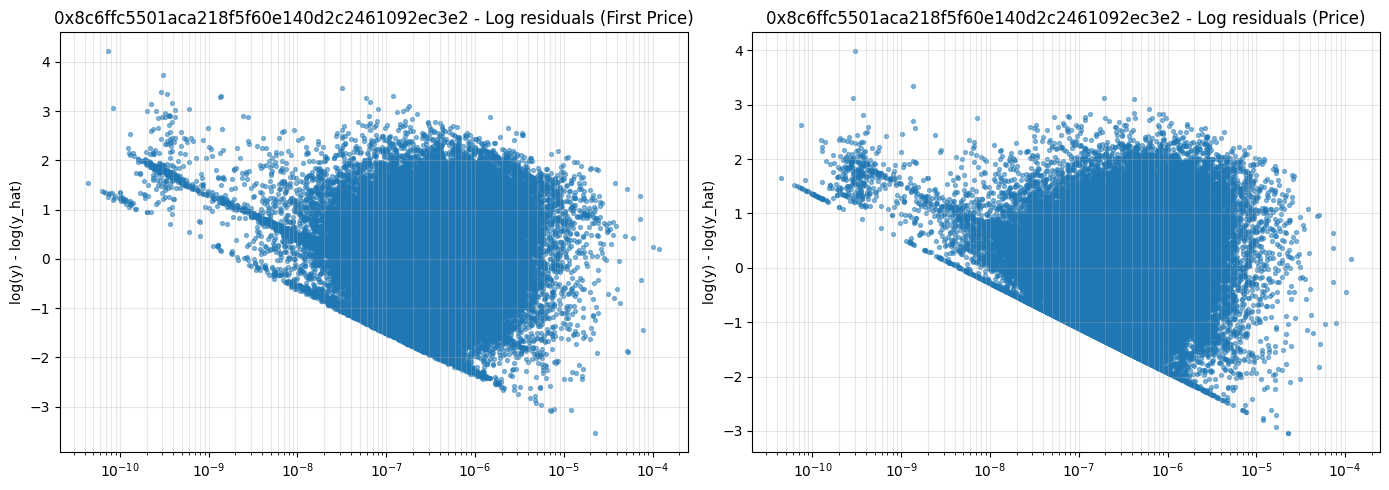

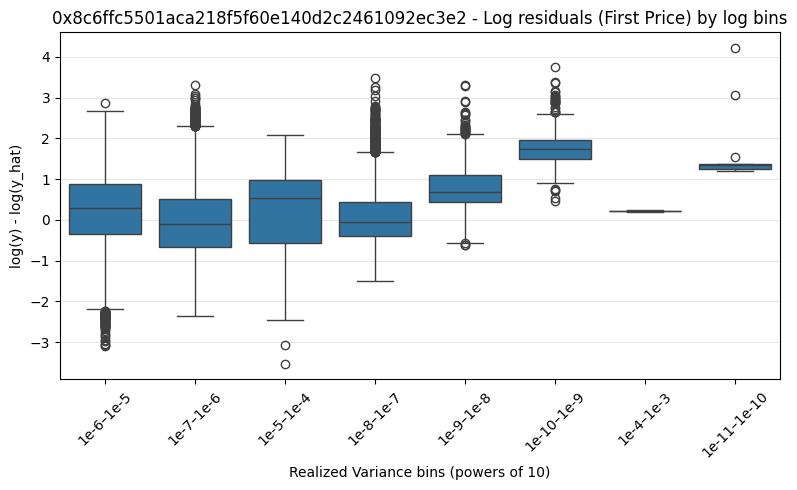

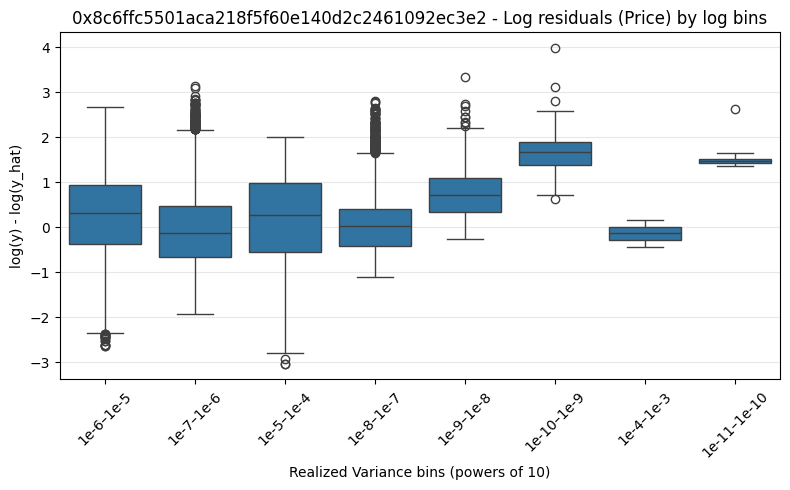

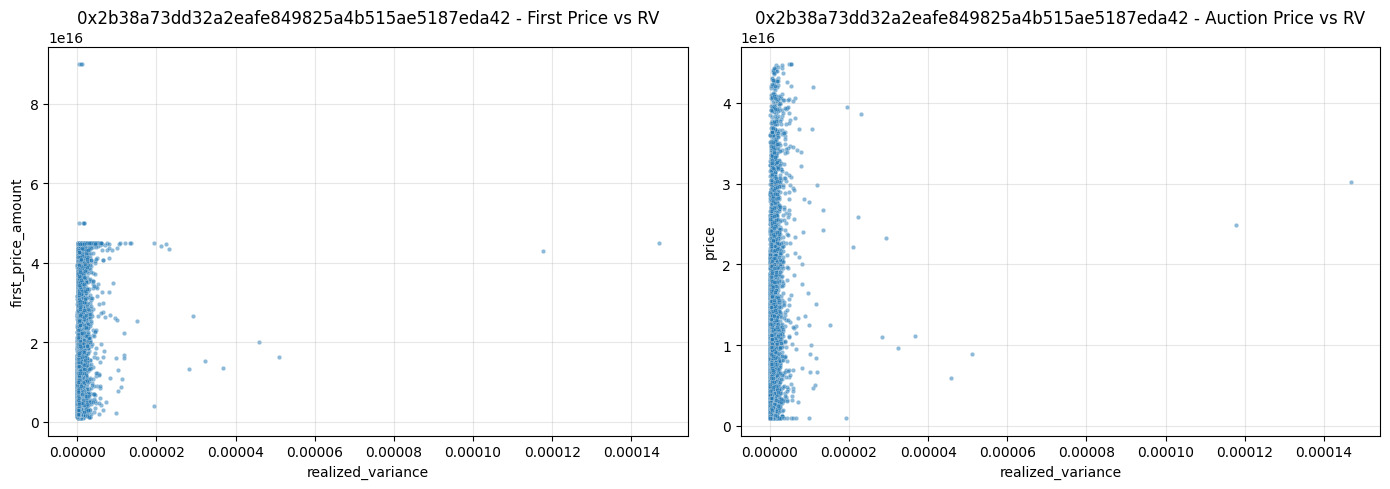

/var/folders/mw/7dlhwf_52t93xrwvltvn_7nr0000gn/T/ipykernel_38587/1828492159.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bdf.groupby("rv_quantile")["first_price_amount"].mean().reindex(labels)
/var/folders/mw/7dlhwf_52t93xrwvltvn_7nr0000gn/T/ipykernel_38587/1828492159.py:50: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means_price = bdf.groupby("rv_quantile")["price"].mean().reindex(labels)


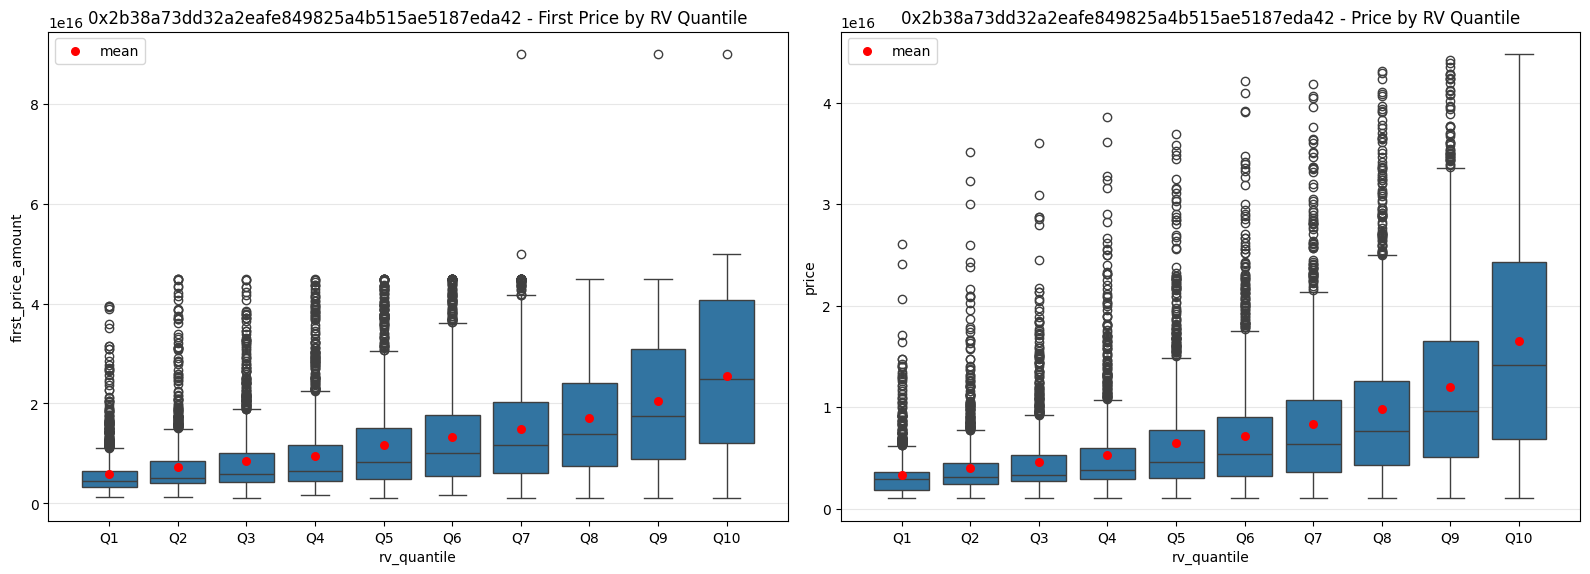

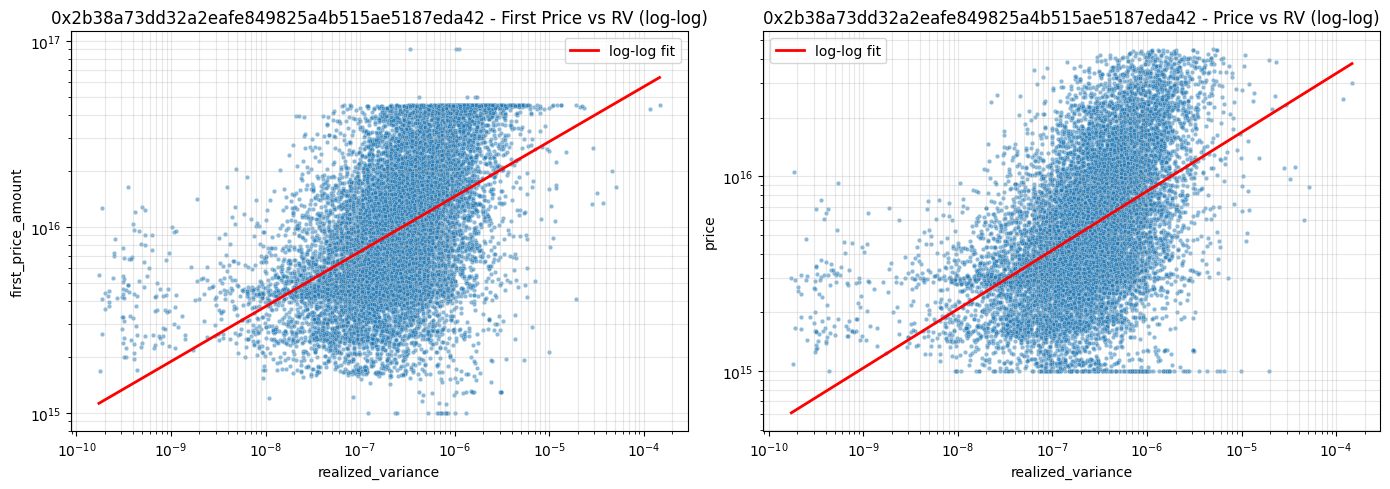

Regression coefficients for 0x2b38a73dd32a2eafe849825a4b515ae5187eda42 (log-log):


,winner,target,model,intercept,slope,n
0,0x2b38a73dd32a2eafe849825a4b515ae5187eda42,first_price_amount,log-log,41.301182,0.295635,13598
1,0x2b38a73dd32a2eafe849825a4b515ae5187eda42,price,log-log,40.844083,0.302476,13598


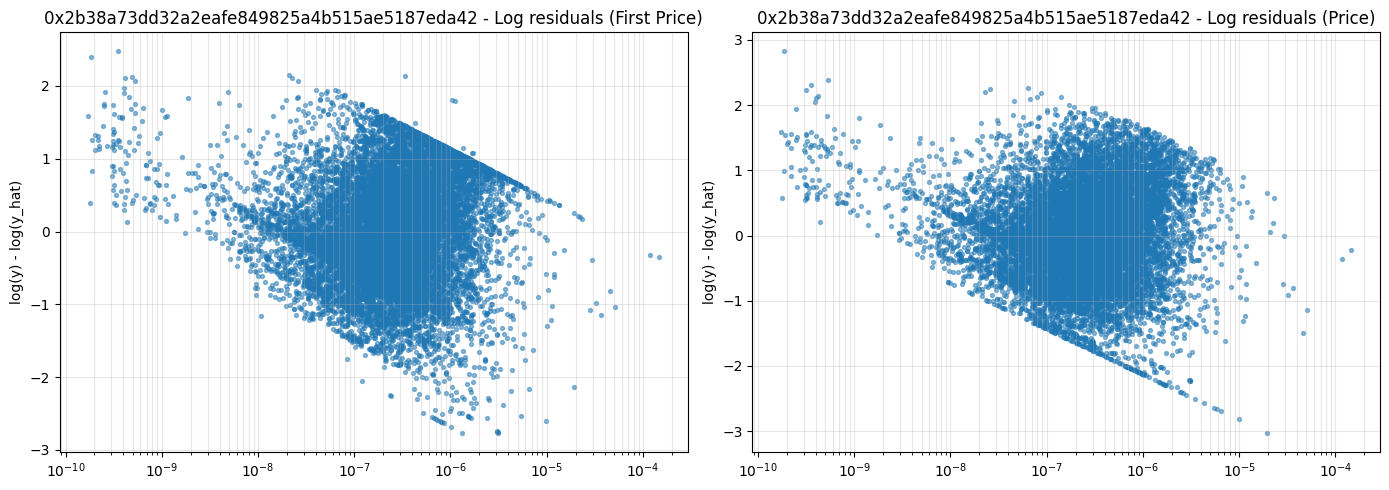

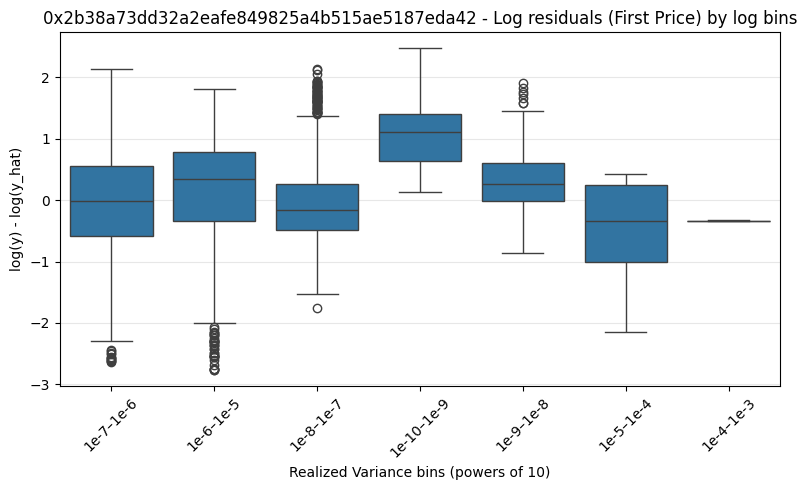

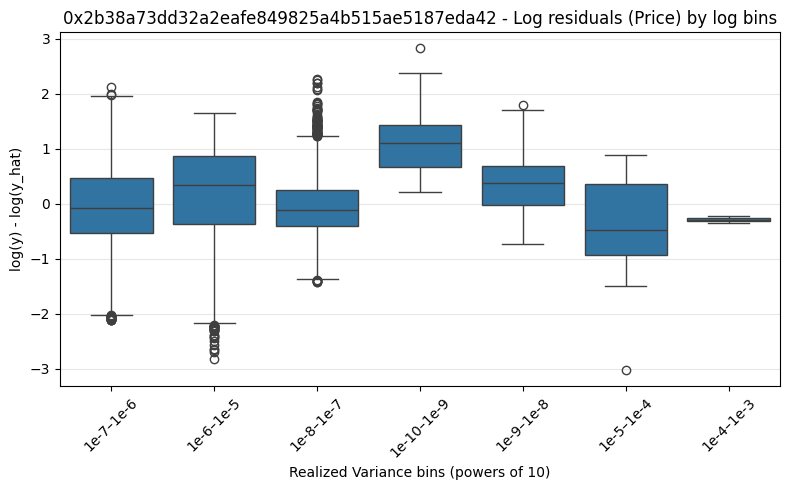

In [12]:
# Run plots and regressions per top winner subset


def plot_all_for_subset(df, winner_label: str):
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(subset=["realized_variance"]).copy()

    # Scatter (linear scales)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
    sns.scatterplot(
        data=df,
        x="realized_variance",
        y="first_price_amount",
        s=10,
        alpha=0.5,
        ax=axes[0],
    )
    axes[0].set_title(f"{winner_label} - First Price vs RV")
    axes[0].grid(True, alpha=0.3)
    sns.scatterplot(
        data=df, x="realized_variance", y="price", s=10, alpha=0.5, ax=axes[1]
    )
    axes[1].set_title(f"{winner_label} - Auction Price vs RV")
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Quantile boxplots with means
    bdf = df.copy()
    num_bins = 10
    labels = [f"Q{i + 1}" for i in range(num_bins)]
    bdf["rv_quantile"] = pd.qcut(bdf["realized_variance"], q=num_bins, labels=labels)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=False)
    sns.boxplot(data=bdf, x="rv_quantile", y="first_price_amount", ax=axes[0])
    means_first = (
        bdf.groupby("rv_quantile")["first_price_amount"].mean().reindex(labels)
    )
    axes[0].scatter(
        np.arange(len(labels)),
        means_first.values,
        color="red",
        s=30,
        zorder=3,
        label="mean",
    )
    axes[0].legend()
    axes[0].set_title(f"{winner_label} - First Price by RV Quantile")
    axes[0].grid(True, axis="y", alpha=0.3)
    sns.boxplot(data=bdf, x="rv_quantile", y="price", ax=axes[1])
    means_price = bdf.groupby("rv_quantile")["price"].mean().reindex(labels)
    axes[1].scatter(
        np.arange(len(labels)),
        means_price.values,
        color="red",
        s=30,
        zorder=3,
        label="mean",
    )
    axes[1].legend()
    axes[1].set_title(f"{winner_label} - Price by RV Quantile")
    axes[1].grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Log-log scatter with regression line
    ldf = df[(df["realized_variance"] > 0)].copy()
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
    # First price
    sdf = ldf[(ldf["first_price_amount"] > 0)][
        ["realized_variance", "first_price_amount"]
    ].dropna()
    sns.scatterplot(
        data=sdf,
        x="realized_variance",
        y="first_price_amount",
        s=10,
        alpha=0.5,
        ax=axes[0],
    )
    axes[0].set_xscale("log")
    axes[0].set_yscale("log")
    X = np.log(sdf["realized_variance"].values).reshape(-1, 1)
    y_log = np.log(sdf["first_price_amount"].values)
    lr = LinearRegression().fit(X, y_log)
    xline = np.linspace(
        sdf["realized_variance"].min(), sdf["realized_variance"].max(), 200
    )
    yline = np.exp(lr.intercept_ + lr.coef_[0] * np.log(xline))
    axes[0].plot(xline, yline, color="red", linewidth=2, label="log-log fit")
    axes[0].legend()
    axes[0].set_title(f"{winner_label} - First Price vs RV (log-log)")
    axes[0].grid(True, which="both", alpha=0.3)
    # Price
    sdfp = ldf[(ldf["price"] > 0)][["realized_variance", "price"]].dropna()
    sns.scatterplot(
        data=sdfp, x="realized_variance", y="price", s=10, alpha=0.5, ax=axes[1]
    )
    axes[1].set_xscale("log")
    axes[1].set_yscale("log")
    Xp = np.log(sdfp["realized_variance"].values).reshape(-1, 1)
    yp_log = np.log(sdfp["price"].values)
    lrp = LinearRegression().fit(Xp, yp_log)
    xlinep = np.linspace(
        sdfp["realized_variance"].min(), sdfp["realized_variance"].max(), 200
    )
    ylinep = np.exp(lrp.intercept_ + lrp.coef_[0] * np.log(xlinep))
    axes[1].plot(xlinep, ylinep, color="red", linewidth=2, label="log-log fit")
    axes[1].legend()
    axes[1].set_title(f"{winner_label} - Price vs RV (log-log)")
    axes[1].grid(True, which="both", alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Print coefficients for log-log fits for this winner
    coeff_df = pd.DataFrame(
        [
            {
                "winner": winner_label,
                "target": "first_price_amount",
                "model": "log-log",
                "intercept": float(lr.intercept_),
                "slope": float(lr.coef_[0]),
                "n": int(len(X)),
            },
            {
                "winner": winner_label,
                "target": "price",
                "model": "log-log",
                "intercept": float(lrp.intercept_),
                "slope": float(lrp.coef_[0]),
                "n": int(len(Xp)),
            },
        ]
    )
    print(f"Regression coefficients for {winner_label} (log-log):")
    display(coeff_df)

    # Log residuals vs RV and binned boxplots (powers of 10)
    # First price
    X = np.log(sdf[["realized_variance"]].values)
    y_log = np.log(sdf[["first_price_amount"]].values).reshape(-1)
    lr = LinearRegression().fit(X, y_log)
    yhat_log = lr.predict(X).reshape(-1)
    resid_log = y_log - yhat_log
    # Price
    Xp = np.log(sdfp[["realized_variance"]].values)
    yp_log = np.log(sdfp[["price"]].values).reshape(-1)
    lrp = LinearRegression().fit(Xp, yp_log)
    yhatp_log = lrp.predict(Xp).reshape(-1)
    residp_log = yp_log - yhatp_log

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
    axes[0].scatter(sdf["realized_variance"].values, resid_log, s=8, alpha=0.5)
    axes[0].set_xscale("log")
    axes[0].set_title(f"{winner_label} - Log residuals (First Price)")
    axes[0].set_ylabel("log(y) - log(y_hat)")
    axes[0].grid(True, which="both", alpha=0.3)
    axes[1].scatter(sdfp["realized_variance"].values, residp_log, s=8, alpha=0.5)
    axes[1].set_xscale("log")
    axes[1].set_title(f"{winner_label} - Log residuals (Price)")
    axes[1].set_ylabel("log(y) - log(y_hat)")
    axes[1].grid(True, which="both", alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Log-scale bins
    def box_by_log_bins(x, resid, title):
        x = np.asarray(x)
        resid = np.asarray(resid)
        all_x = x
        min_exp = int(np.floor(np.log10(all_x.min())))
        max_exp = int(np.ceil(np.log10(all_x.max())))
        bin_edges = np.power(10.0, np.arange(min_exp, max_exp + 1))
        idx = np.digitize(all_x, bins=bin_edges, right=False)
        bdf = pd.DataFrame({"bin": idx, "resid_log": resid})
        bdf = bdf[(bdf["bin"] >= 1) & (bdf["bin"] <= len(bin_edges) - 1)]
        labels = [f"1e{e}–1e{e + 1}" for e in range(min_exp, max_exp)]
        bdf["bin_label"] = bdf["bin"].map(
            lambda i: labels[i - 1] if 1 <= i <= len(labels) else None
        )
        plt.figure(figsize=(8, 5))
        sns.boxplot(data=bdf, x="bin_label", y="resid_log")
        plt.title(title)
        plt.xlabel("Realized Variance bins (powers of 10)")
        plt.ylabel("log(y) - log(y_hat)")
        plt.xticks(rotation=45)
        plt.grid(True, axis="y", alpha=0.3)
        plt.tight_layout()
        plt.show()

    box_by_log_bins(
        sdf["realized_variance"].values,
        resid_log,
        f"{winner_label} - Log residuals (First Price) by log bins",
    )
    box_by_log_bins(
        sdfp["realized_variance"].values,
        residp_log,
        f"{winner_label} - Log residuals (Price) by log bins",
    )


# Execute for each top winner
for w, df in winner_subsets.items():
    plot_all_for_subset(df, winner_label=w)

# Note: per-winner cells above include regression fits; no extra coefficients here.

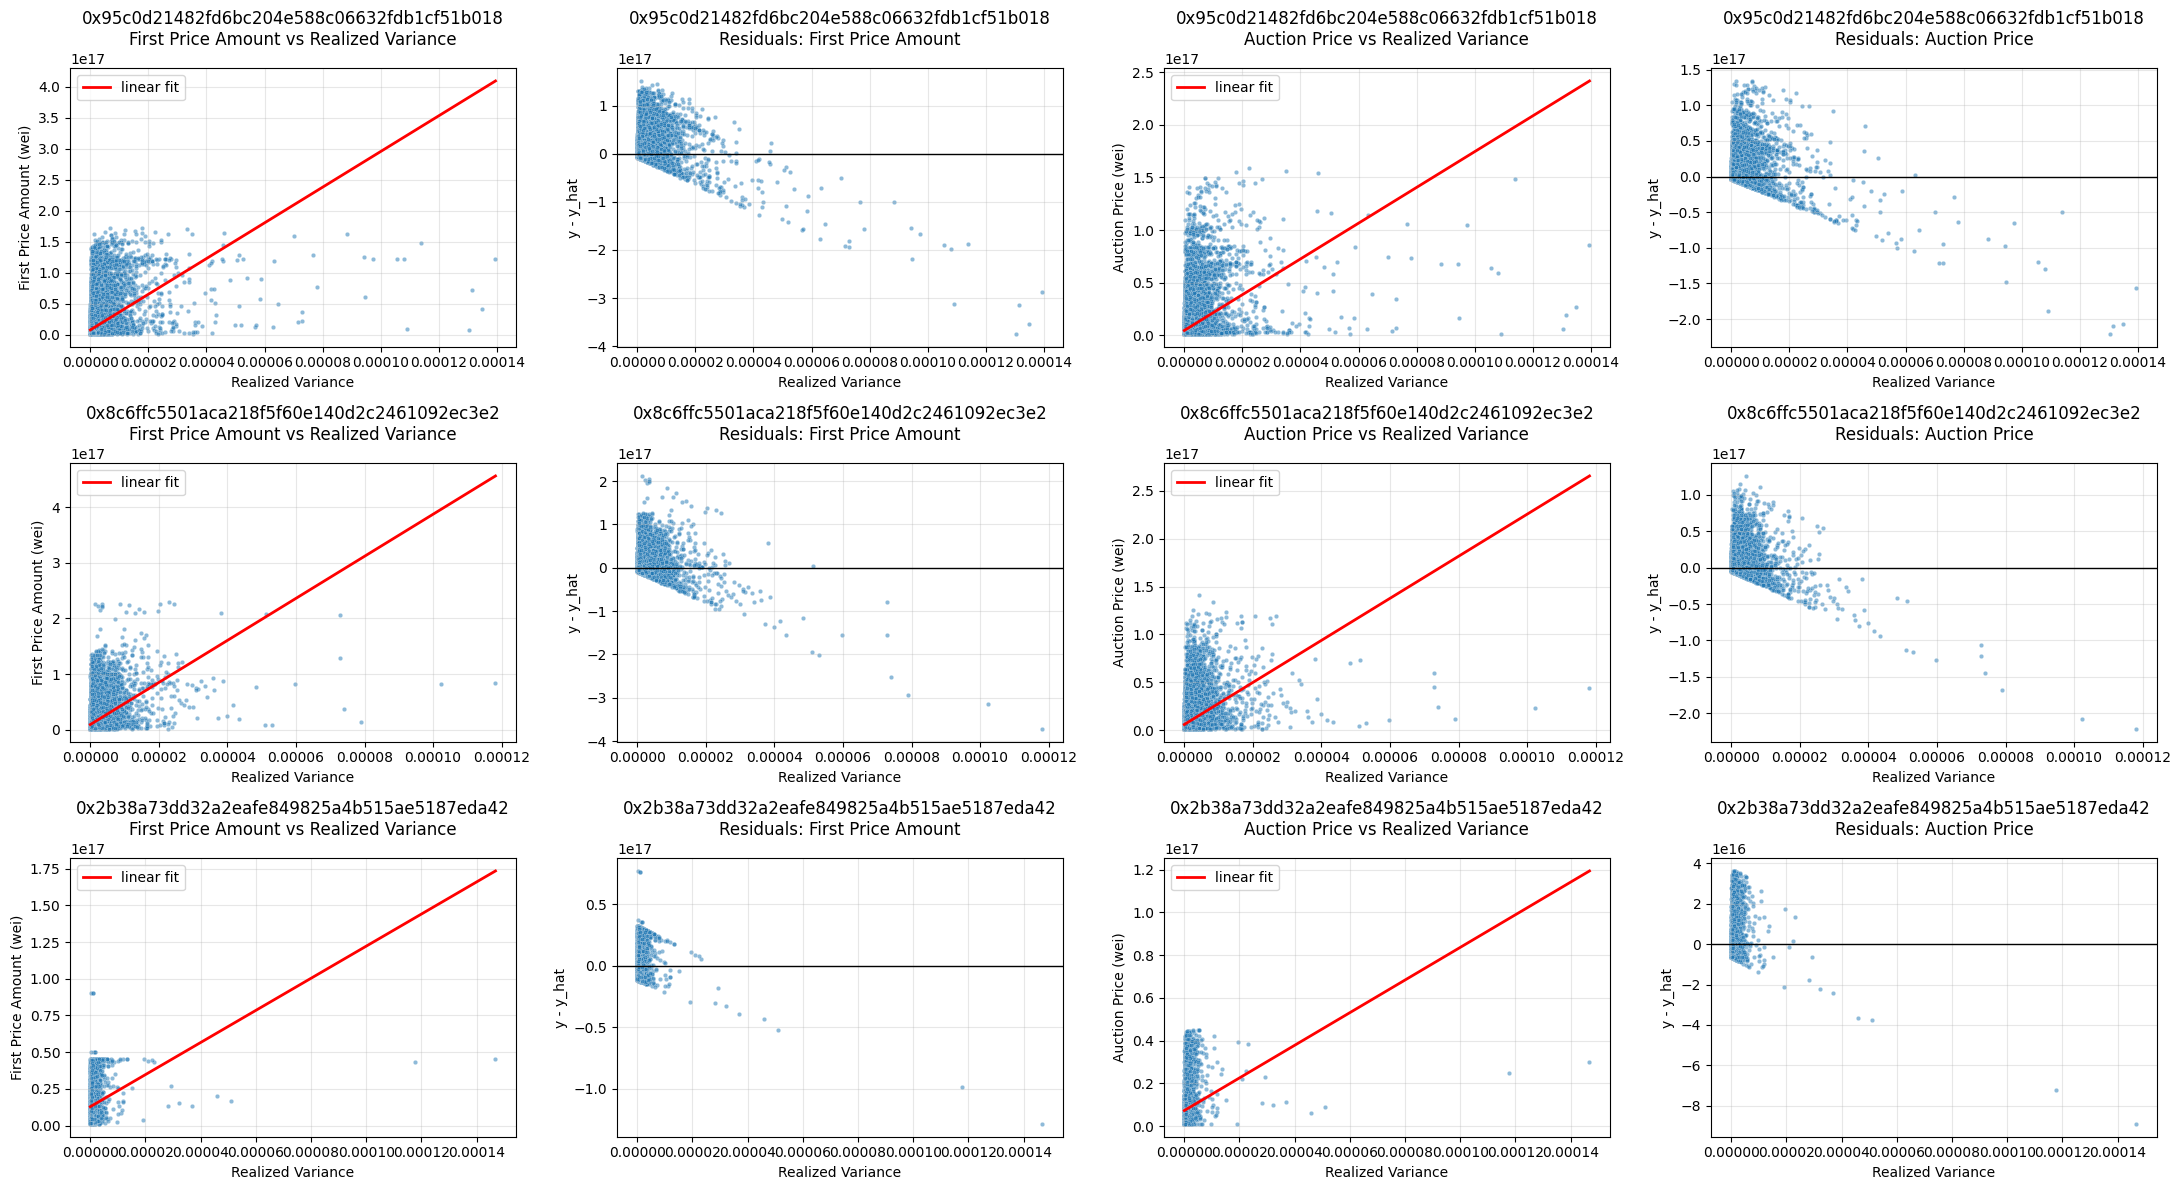

Regression coefficients (linear scale):


,winner,target,intercept,slope,n
0,0x95c0d21482fd6bc204e588c06632fdb1cf51b018,first_price_amount,7.641192e+15,2.878887e+21,110832
1,0x95c0d21482fd6bc204e588c06632fdb1cf51b018,price,4.421924e+15,1.702108e+21,110832
2,0x8c6ffc5501aca218f5f60e140d2c2461092ec3e2,first_price_amount,9.165533e+15,3.782103e+21,70454
3,0x8c6ffc5501aca218f5f60e140d2c2461092ec3e2,price,5.769468e+15,2.198950e+21,70454
4,0x2b38a73dd32a2eafe849825a4b515ae5187eda42,first_price_amount,1.282681e+16,1.093738e+21,13598
5,0x2b38a73dd32a2eafe849825a4b515ae5187eda42,price,7.321592e+15,7.628254e+20,13598


In [13]:
# Single-cell, single-figure: linear-scale plots with regression and residuals for top 3 bidders (3x4 grid)

# Ensure we have top3_winners and winner_subsets from earlier cell
assert "top3_winners" in globals() and "winner_subsets" in globals(), (
    "Run the top-3 winners cell first."
)

fig, axes = plt.subplots(3, 4, figsize=(22, 12), sharex=False)

coeff_rows = []  # collect regression coefficients

for row, w in enumerate(top3_winners):
    df = winner_subsets[w].copy()
    df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=["realized_variance"])

    # Prepare helper for regression and plotting
    def scatter_with_reg(ax, x, y, title, y_label, target_label):
        sns.scatterplot(x=x, y=y, s=10, alpha=0.5, ax=ax)
        # Fit linear regression on original scales: y = a + b x
        X = np.asarray(x).reshape(-1, 1)
        Y = np.asarray(y)
        if len(X) >= 2:
            lr = LinearRegression().fit(X, Y)
            xline = np.linspace(np.min(X), np.max(X), 200)
            yline = lr.intercept_ + lr.coef_[0] * xline
            ax.plot(xline, yline, color="red", linewidth=2, label="linear fit")
            ax.legend()
            yhat = lr.predict(X)
            coeff_rows.append(
                {
                    "winner": w,
                    "target": target_label,
                    "intercept": float(lr.intercept_),
                    "slope": float(lr.coef_[0]),
                    "n": int(len(X)),
                }
            )
        else:
            yhat = np.full_like(Y, fill_value=np.nan, dtype=float)
            coeff_rows.append(
                {
                    "winner": w,
                    "target": target_label,
                    "intercept": np.nan,
                    "slope": np.nan,
                    "n": int(len(X)),
                }
            )
        ax.set_title(title)
        ax.set_xlabel("Realized Variance")
        ax.set_ylabel(y_label)
        ax.grid(True, alpha=0.3)
        return Y - yhat

    # Columns: [FP scatter+reg, FP residuals, Price scatter+reg, Price residuals]
    # First Price Amount
    ax_fp = axes[row, 0]
    resid_fp = scatter_with_reg(
        ax_fp,
        x=df["realized_variance"].values,
        y=df["first_price_amount"].values,
        title=f"{w}\nFirst Price Amount vs Realized Variance",
        y_label="First Price Amount (wei)",
        target_label="first_price_amount",
    )
    # Residuals for First Price Amount
    ax_fp_res = axes[row, 1]
    sns.scatterplot(
        x=df["realized_variance"].values, y=resid_fp, s=10, alpha=0.5, ax=ax_fp_res
    )
    ax_fp_res.axhline(0.0, color="black", linewidth=1)
    ax_fp_res.set_title(f"{w}\nResiduals: First Price Amount")
    ax_fp_res.set_xlabel("Realized Variance")
    ax_fp_res.set_ylabel("y - y_hat")
    ax_fp_res.grid(True, alpha=0.3)

    # Auction Price
    ax_p = axes[row, 2]
    resid_p = scatter_with_reg(
        ax_p,
        x=df["realized_variance"].values,
        y=df["price"].values,
        title=f"{w}\nAuction Price vs Realized Variance",
        y_label="Auction Price (wei)",
        target_label="price",
    )
    # Residuals for Auction Price
    ax_p_res = axes[row, 3]
    sns.scatterplot(
        x=df["realized_variance"].values, y=resid_p, s=10, alpha=0.5, ax=ax_p_res
    )
    ax_p_res.axhline(0.0, color="black", linewidth=1)
    ax_p_res.set_title(f"{w}\nResiduals: Auction Price")
    ax_p_res.set_xlabel("Realized Variance")
    ax_p_res.set_ylabel("y - y_hat")
    ax_p_res.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print coefficients as a small table
coeff_df = pd.DataFrame(
    coeff_rows, columns=["winner", "target", "intercept", "slope", "n"]
)
print("Regression coefficients (linear scale):")
display(coeff_df)

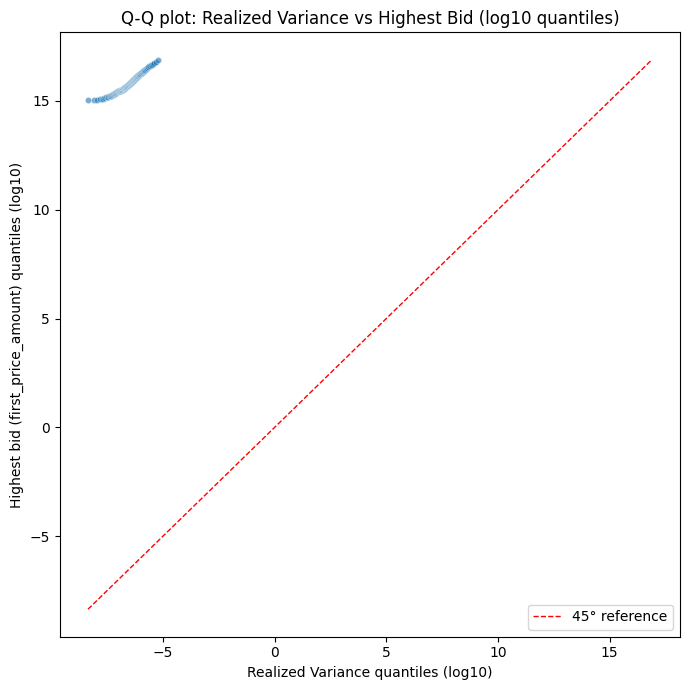

In [16]:
# Q-Q plot: Realized Variance vs Highest Bid (first_price_amount)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data: keep positive, finite values
_qq_df = auctions_with_rv[["realized_variance", "first_price_amount"]].copy()
_qq_df = _qq_df.replace([np.inf, -np.inf], np.nan).dropna()
_qq_df = _qq_df[(_qq_df["realized_variance"] > 0) & (_qq_df["first_price_amount"] > 0)]

if _qq_df.empty:
    print("No data available for Q-Q plot (after filtering).")
else:
    # Use common quantile grid (avoid extremes)
    _q = np.linspace(0.01, 0.99, 199)
    _rv_q = np.log10(_qq_df["realized_variance"].quantile(_q).values)
    _fp_q = np.log10(_qq_df["first_price_amount"].quantile(_q).values)

    fig, ax = plt.subplots(figsize=(7, 7))
    sns.scatterplot(x=_rv_q, y=_fp_q, s=20, alpha=0.6, ax=ax)

    # 45-degree reference line
    _mn = float(np.nanmin((_rv_q.min(), _fp_q.min())))
    _mx = float(np.nanmax((_rv_q.max(), _fp_q.max())))
    ax.plot([_mn, _mx], [_mn, _mx], "--", color="red", linewidth=1, label="45° reference")

    ax.set_xlabel("Realized Variance quantiles (log10)")
    ax.set_ylabel("Highest bid (first_price_amount) quantiles (log10)")
    ax.set_title("Q-Q plot: Realized Variance vs Highest Bid (log10 quantiles)")
    ax.legend()
    plt.tight_layout()
    plt.show()

